<summary><span style="font-size:30px; font-weight:bold;">3. Data Preparation </span></summary>

## 3.1 Check Data

In [2]:
import pandas as pd
demo = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/DEMO_L.xpt", format="xport")
mcq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/MCQ_L.xpt", format="xport")
bpq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/BPQ_L.xpt", format="xport")
diq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/DIQ_L.xpt", format="xport")
huq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/HUQ_L.xpt", format="xport")
fnq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/FNQ_L.xpt", format="xport")

In [3]:
print("demo:", demo.shape) ## Data volume
print("mcq:", mcq.shape)
print("bpq:", bpq.shape)
print("diq:", diq.shape)
print("huq:", huq.shape)
print("fnq:", fnq.shape)

demo: (11933, 27)
mcq: (11744, 35)
bpq: (8501, 6)
diq: (11744, 9)
huq: (11933, 6)
fnq: (10942, 32)


In [4]:
print("SEQN in demo:", "SEQN" in demo.columns) ## check SEQN
print("SEQN in mcq:", "SEQN" in mcq.columns)
print("SEQN in bpq:", "SEQN" in bpq.columns)
print("SEQN in diq:", "SEQN" in diq.columns)
print("SEQN in huq:", "SEQN" in huq.columns)
print("SEQN in fnq:", "SEQN" in fnq.columns)

SEQN in demo: True
SEQN in mcq: True
SEQN in bpq: True
SEQN in diq: True
SEQN in huq: True
SEQN in fnq: True


In [5]:
## Screening the elderly aged 65 and above
elderly_demo = demo[demo["RIDAGEYR"] >= 65].copy()
print(elderly_demo.shape)
elderly_demo.head()

(2586, 27)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,29087.450605,3.408472e+04,173.0,2.0,5.00
7,130385.0,12.0,1.0,2.0,65.0,NaN,3.0,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,16151.033173,5.397605e-79,187.0,2.0,5.00
9,130387.0,12.0,2.0,2.0,68.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,19896.970559,2.077625e+04,181.0,1.0,1.32
14,130392.0,12.0,2.0,2.0,74.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,25064.248864,2.942777e+04,174.0,1.0,3.04
19,130397.0,12.0,2.0,2.0,67.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,32394.280442,3.803740e+04,179.0,2.0,4.48


In [6]:
## Merge data
merged = elderly_demo.merge(mcq, on="SEQN", how="left")
merged = merged.merge(bpq, on="SEQN", how="left")
merged = merged.merge(diq, on="SEQN", how="left")
merged = merged.merge(huq, on="SEQN", how="left")
merged = merged.merge(fnq, on="SEQN", how="left")
print(merged.shape)
merged.head()

(2586, 110)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,FNQ460,FNQ470,FNQ480,FNQ490,FNQ510,FNQ520,FNQ530,FNQ540,FNDADI,FNDAEDI
0,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,1.0,1.0,1.0,1.0,4.0,1.0,5.0,NaN,2.0,2.0
1,130385.0,12.0,1.0,2.0,65.0,NaN,3.0,3.0,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,1.0,4.0,1.0,2.0,2.0
2,130387.0,12.0,2.0,2.0,68.0,NaN,3.0,3.0,2.0,NaN,...,1.0,2.0,1.0,1.0,2.0,1.0,5.0,NaN,2.0,2.0
3,130392.0,12.0,2.0,2.0,74.0,NaN,3.0,3.0,2.0,NaN,...,1.0,1.0,1.0,3.0,4.0,1.0,4.0,1.0,2.0,1.0
4,130397.0,12.0,2.0,2.0,67.0,NaN,3.0,3.0,1.0,NaN,...,1.0,1.0,1.0,1.0,1.0,3.0,2.0,3.0,2.0,2.0


In [7]:
print(merged.columns.tolist())

['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4', 'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR', 'MCQ010', 'MCQ035', 'MCQ040', 'MCQ050', 'AGQ030', 'MCQ053', 'MCQ149', 'MCQ160A', 'MCQ195', 'MCQ160B', 'MCQ160C', 'MCQ160D', 'MCQ160E', 'MCQ160F', 'MCQ160M', 'MCQ170M', 'MCQ160P', 'MCQ160L', 'MCQ170L', 'MCQ500', 'MCQ510A', 'MCQ510B', 'MCQ510C', 'MCQ510D', 'MCQ510E', 'MCQ510F', 'MCQ550', 'MCQ560', 'MCQ220', 'MCQ230A', 'MCQ230B', 'MCQ230C', 'MCQ230D', 'OSQ230', 'BPQ020', 'BPQ030', 'BPQ150', 'BPQ080', 'BPQ101D', 'DIQ010', 'DID040', 'DIQ160', 'DIQ180', 'DIQ050', 'DID060', 'DIQ060U', 'DIQ070', 'HUQ010', 'HUQ030', 'HUQ042', 'HUQ055', 'HUQ090', 'FNQ021', 'FNQ041', 'FNQ050', 'FNQ060', 'FNQ080', 'FNQ160', 'FNQ100', 'FNQ110', 'FNQ120', 'FNQ170', 'FNQ180', 'FNQ190', 'FNQ130', 'FNQ200

## 3.2 Full Variables and Codebook Descriptions

### 3.2.1 Demographic Variables

| Variable | Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Unique respondent identifier used for merging datasets |
| SDDSRVYR | Data release cycle | Survey cycle information |
| RIDSTATR | Interview/Examination status | Participant interview and examination status |
| RIAGENDR | Gender | Demographic feature |
| RIDAGEYR | Age in years at screening | Used to filter participants aged 65 and above |
| RIDAGEMN | Age in months at screening (0 to 24 months) | Applicable mainly to infants/young children |
| RIDRETH1 | Race/Hispanic origin | Demographic feature |
| RIDRETH3 | Race/Hispanic origin with NH Asian | Extended race/ethnicity classification |
| RIDEXMON | Six-month time period | Examination period indicator |
| RIDEXAGM | Age in months at exam (0 to 19 years) | Mainly for children/adolescents |
| DMQMILIZ | Served active duty in US Armed Forces | Military service variable |
| DMDBORN4 | Country of birth | Demographic feature |
| DMDYRUSR | Length of time in US | Immigration-related variable |
| DMDEDUC2 | Education level - Adults 20+ | Socioeconomic feature |
| DMDMARTZ | Marital status | Demographic feature |
| RIDEXPRG | Pregnancy status at exam | Mainly relevant to female participants of childbearing age |
| DMDHHSIZ | Total number of people in household | Household structure variable |
| DMDHRGND | Household reference person’s gender | Household-level variable |
| DMDHRAGZ | Household reference person’s age in years | Household-level variable |
| DMDHREDZ | Household reference person’s education level | Household-level variable |
| DMDHRMAZ | Household reference person’s marital status | Household-level variable |
| DMDHSEDZ | Household reference person’s spouse’s education level | Household-level variable |
| WTINT2YR | Full sample 2-year interview weight | Sampling weight variable |
| WTMEC2YR | Full sample 2-year MEC exam weight | Sampling weight variable |
| SDMVSTRA | Masked variance pseudo-stratum | Survey design variable |
| SDMVPSU | Masked variance pseudo-PSU | Survey design variable |
| INDFMPIR | Ratio of family income to poverty | Socioeconomic feature |

### 3.2.2 Medical Conditions Variables

| Variable | Description | Notes |
|---|---|---|
| MCQ010 | Ever been told you have asthma | Chronic respiratory condition |
| MCQ035 | Still have asthma | Current asthma status |
| MCQ040 | Had asthma attack in past year | Asthma severity indicator |
| MCQ050 | Emergency care visit for asthma / past year | Healthcare utilization related to asthma |
| AGQ030 | Did SP have episode of hay fever / past year | Allergy-related condition |
| MCQ053 | Taking treatment for anemia / past 3 months | Recent treatment variable |
| MCQ149 | Menstrual periods started yet? | Biological history variable; likely not relevant for elderly analysis |
| MCQ160A | Doctor ever said you had arthritis | Chronic musculoskeletal condition |
| MCQ160B | Ever told had congestive heart failure | Cardiovascular disease variable |
| MCQ160C | Ever told you had coronary heart disease | Cardiovascular disease variable |
| MCQ160D | Ever told you had angina / angina pectoris | Cardiovascular disease variable |
| MCQ160E | Ever told you had heart attack | Cardiovascular disease variable |
| MCQ160F | Ever told you had a stroke | Cardiovascular / neurological disease variable |
| MCQ160M | Ever told you had thyroid problem | Chronic disease variable |
| MCQ160P | Ever told you had COPD, emphysema, or chronic bronchitis | Chronic respiratory disease variable |
| MCQ160L | Ever told you had any liver condition | Chronic disease variable |
| MCQ170M | Do you still have thyroid problem | Current thyroid condition |
| MCQ170L | Do you still have a liver condition | Current liver condition |
| MCQ500 | Ever told you had any liver condition | Liver disease screening variable |
| MCQ510A | Liver condition: Fatty liver | Specific liver disease type |
| MCQ510B | Liver condition: Liver fibrosis | Specific liver disease type |
| MCQ510C | Liver condition: Liver cirrhosis | Specific liver disease type |
| MCQ510D | Liver condition: Viral hepatitis | Specific liver disease type |
| MCQ510E | Liver condition: Autoimmune hepatitis | Specific liver disease type |
| MCQ510F | Liver condition: Other liver disease | Specific liver disease type |
| MCQ550 | Has doctor ever said you have gallstones | Gallbladder-related condition |
| MCQ560 | Ever had gallbladder surgery? | Surgical history variable |
| MCQ220 | Ever told you had cancer or malignancy | Major chronic disease variable |
| MCQ230A | 1st cancer - what kind was it? | Cancer type detail |
| MCQ230B | 2nd cancer - what kind was it? | Cancer type detail |
| MCQ230C | 3rd cancer - what kind was it? | Cancer type detail |
| MCQ230D | More than 3 kinds of cancer | Cancer history detail |
| OSQ230 | Any metal objects inside your body? | Medical history / examination-related variable |

### 3.2.3 Blood Pressure and Cholesterol Variables

| Variable | Description | Notes |
|---|---|---|
| BPQ020 | Ever told you had high blood pressure | Core chronic disease variable |
| BPQ030 | Told had high blood pressure 2+ times | Hypertension confirmation variable |
| BPQ150 | Taking high blood pressure medication | Hypertension treatment variable |
| BPQ080 | Doctor told you - high cholesterol level | Lipid disorder variable |
| BPQ101D | Taking meds to lower blood cholesterol | Cholesterol treatment variable |

### 3.2.4 Diabetes Variables

| Variable | Description | Notes |
|---|---|---|
| DIQ010 | Doctor told you have diabetes | Core chronic disease variable |
| DID040 | Age when first told you had diabetes | Diabetes history variable |
| DIQ160 | Ever told you have prediabetes | Additional metabolic risk variable |
| DIQ180 | Had blood tested past three years | Health monitoring variable |
| DIQ050 | Taking insulin now | Diabetes treatment variable |
| DID060 | How long taking insulin | Diabetes treatment duration |
| DIQ060U | Unit of measure (month/year) | Time unit for insulin duration |
| DIQ070 | Take diabetic pills to lower blood sugar | Diabetes treatment variable |

### 3.2.5 Hospital Utilization and Access to Care Variables

| Variable | Description | Notes |
|---|---|---|
| HUQ010 | General health condition | Important health status variable |
| HUQ030 | Routine place to go for healthcare | Healthcare access variable |
| HUQ042 | Type place most often go for healthcare | Healthcare service usage variable |
| HUQ055 | Past 12 months had video conference with doctor | Telehealth / healthcare access variable |
| HUQ090 | Seen mental health professional / past year | Mental healthcare utilization variable |

### 3.2.6 Functioning Variables

| Variable | Description | Notes |
|---|---|---|
| FNQ021 | Difficulty seeing even with glasses | Functional limitation variable |
| FNQ041 | Difficulty hearing even with hearing aids | Functional limitation variable |
| FNQ050 | Use equipment or assistance for walking | Mobility support variable |
| FNQ060 | Difficulty walking 100 yards without equipment | Mobility limitation variable |
| FNQ080 | Difficulty walking 100 yards | Mobility limitation variable |
| FNQ160 | Difficulty with self-care | Functional limitation variable |
| FNQ100 | Difficulty being understood inside household | Communication limitation variable |
| FNQ110 | Difficulty being understood outside household | Communication limitation variable |
| FNQ120 | Difficulty learning things | Cognitive limitation variable |
| FNQ170 | Difficulty remembering things | Cognitive limitation variable |
| FNQ180 | Difficulty concentrating | Cognitive limitation variable |
| FNQ190 | Difficulty accepting change | Behavioral / cognitive limitation variable |
| FNQ130 | Difficulty controlling behavior | Behavioral limitation variable |
| FNQ200 | Difficulty making friends | Social functioning variable |
| FNQ140 | How often very anxious / nervous / worried | Mental health frequency variable |
| FNQ150 | How often very sad / depressed | Mental health frequency variable |
| FNQDCDI* | CFM Disability Indicator for 5–17 years | Present in merged columns list; verify exact spelling in dataset if needed |
| FNQ410 | Difficulty seeing even with glasses | Adult functioning variable |
| FNQ430 | Difficulty hearing even with hearing aids | Adult functioning variable |
| FNQ440 | Difficulty walking or climbing steps | Mobility limitation variable |
| FNQ450 | Difficulty communicating | Communication limitation variable |
| FNQ460 | Difficulty remembering or concentrating | Cognitive limitation variable |
| FNQ470 | Difficulty with self-care | Daily living limitation variable |
| FNQ480 | Difficulty raising a 2-liter bottle | Upper-body functioning variable |
| FNQ490 | Difficulty using hands and fingers | Fine motor limitation variable |
| FNQ510 | How often feel worried / nervous / anxious | Mental health frequency variable |
| FNQ520 | Level of feeling worried / nervous / anxious | Mental health severity variable |
| FNQ530 | How often feel depressed | Mental health frequency variable |
| FNQ540 | Level of feeling depressed | Mental health severity variable |
| FNDADI | WG-SS Disability Indicator 18+ | Disability indicator for adults |
| FNDAEDI | WG-SS Enhanced Disability Indicator 18+ | Enhanced disability indicator for adults |

## 3.3 Filter variables

After merging the six NHANES datasets, the analytical dataset initially contained 110 variables.  
Based on the research objective, 47 relevant variables were shortlisted for further analysis.  
These selected variables covered demographic characteristics, chronic conditions, health status, healthcare access, and functioning-related indicators.

In [8]:
keep_cols = [
    'SEQN', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'INDFMPIR',

    'DIQ010', 'DIQ160', 'DIQ050', 'DIQ070',
    'BPQ020', 'BPQ030', 'BPQ150', 'BPQ080', 'BPQ101D',

    'MCQ160A', 'MCQ160B', 'MCQ160C', 'MCQ160D', 'MCQ160E', 'MCQ160F',
    'MCQ160P', 'MCQ160L', 'MCQ220', 'MCQ550', 'MCQ560',

    'HUQ010', 'HUQ030', 'HUQ042', 'HUQ090',

    'FNQ050', 'FNQ060', 'FNQ080', 'FNQ160',
    'FNQ170', 'FNQ180',
    'FNQ410', 'FNQ430', 'FNQ440', 'FNQ450', 'FNQ460', 'FNQ470',
    'FNQ480', 'FNQ490', 'FNQ510', 'FNQ530',
    'FNDADI', 'FNDAEDI'
]

selected = merged[keep_cols].copy()
print(selected.shape)
selected.head()

(2586, 47)


,SEQN,RIAGENDR,RIDAGEYR,RIDRETH1,INDFMPIR,DIQ010,DIQ160,DIQ050,DIQ070,BPQ020,...,FNQ440,FNQ450,FNQ460,FNQ470,FNQ480,FNQ490,FNQ510,FNQ530,FNDADI,FNDAEDI
0,130379.0,1.0,66.0,3.0,5.00,2.0,2.0,NaN,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,4.0,5.0,2.0,2.0
1,130385.0,2.0,65.0,3.0,5.00,2.0,1.0,NaN,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,2.0,2.0
2,130387.0,2.0,68.0,3.0,1.32,2.0,2.0,NaN,NaN,1.0,...,2.0,1.0,1.0,2.0,1.0,1.0,2.0,5.0,2.0,2.0
3,130392.0,2.0,74.0,3.0,3.04,2.0,2.0,NaN,NaN,1.0,...,2.0,1.0,1.0,1.0,1.0,3.0,4.0,4.0,2.0,1.0
4,130397.0,2.0,67.0,3.0,4.48,2.0,1.0,NaN,2.0,2.0,...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0


The variables shown below were retained after the initial screening process. These variables were selected based on their relevance to demographic characteristics, chronic conditions, healthcare access, health status, and functioning among older adults.


### 3.3.1 Demographic Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Unique respondent identifier used for merging datasets |
| RIAGENDR | Gender | Demographic feature |
| RIDAGEYR | Age in years at screening | Used to filter participants aged 65 and above |
| RIDRETH1 | Race/Hispanic origin | Demographic feature |
| INDFMPIR | Ratio of family income to poverty | Socioeconomic feature |

### 3.3.2 Diabetes Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| DIQ010 | Doctor told you have diabetes | Core chronic disease variable |
| DIQ160 | Ever told you have prediabetes | Additional metabolic risk variable |
| DIQ050 | Taking insulin now | Diabetes treatment variable |
| DIQ070 | Take diabetic pills to lower blood sugar | Diabetes treatment variable |

### 3.3.3 Blood Pressure and Cholesterol Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| BPQ020 | Ever told you had high blood pressure | Core chronic disease variable |
| BPQ030 | Told had high blood pressure 2+ times | Hypertension confirmation variable |
| BPQ150 | Taking high blood pressure medication | Hypertension treatment variable |
| BPQ080 | Doctor told you - high cholesterol level | Lipid disorder variable |
| BPQ101D | Taking meds to lower blood cholesterol | Cholesterol treatment variable |

### 3.3.4 Medical Conditions Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| MCQ160A | Doctor ever said you had arthritis | Chronic musculoskeletal condition |
| MCQ160B | Ever told had congestive heart failure | Cardiovascular disease variable |
| MCQ160C | Ever told you had coronary heart disease | Cardiovascular disease variable |
| MCQ160D | Ever told you had angina/angina pectoris | Cardiovascular disease variable |
| MCQ160E | Ever told you had heart attack | Cardiovascular disease variable |
| MCQ160F | Ever told you had a stroke | Cardiovascular/neurological disease variable |
| MCQ160P | Ever told you had COPD, emphysema, chronic bronchitis | Chronic respiratory disease variable |
| MCQ160L | Ever told you had any liver condition | Chronic disease variable |
| MCQ220 | Ever told you had cancer or malignancy | Major chronic disease variable |
| MCQ550 | Has doctor ever said you have gallstones | Gallbladder-related condition |
| MCQ560 | Ever had gallbladder surgery? | Surgical history variable |

### 3.3.5 Healthcare Access and Health Status Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| HUQ010 | General health condition | Important health status variable |
| HUQ030 | Routine place to go for healthcare | Healthcare access variable |
| HUQ042 | Type place most often go for healthcare | Healthcare service usage variable |
| HUQ090 | Seen mental health professional/past year | Mental healthcare utilization variable |

### 3.3.6 Functioning Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| FNQ050 | Use equipment or assistance for walking | Mobility support variable |
| FNQ060 | Difficulty walking 100 yards without equipment | Mobility limitation variable |
| FNQ080 | Difficulty walking 100 yards | Mobility limitation variable |
| FNQ160 | Difficulty with self-care | Functional limitation variable |
| FNQ170 | Difficulty remembering things | Cognitive limitation variable |
| FNQ180 | Difficulty concentrating | Cognitive limitation variable |
| FNQ410 | Difficulty seeing even with glasses | Adult functioning variable |
| FNQ430 | Difficulty hearing even with hearing aids | Adult functioning variable |
| FNQ440 | Difficulty walking or climbing steps | Mobility limitation variable |
| FNQ450 | Difficulty communicating | Communication limitation variable |
| FNQ460 | Difficulty remembering or concentrating | Cognitive limitation variable |
| FNQ470 | Difficulty with self-care | Daily living limitation variable |
| FNQ480 | Difficulty raising a 2-liter bottle | Upper-body functioning variable |
| FNQ490 | Difficulty using hands and fingers | Fine motor limitation variable |
| FNQ510 | How often feel worried/nervous/anxious | Mental health frequency variable |
| FNQ530 | How often feel depressed | Mental health frequency variable |
| FNDADI | WG-SS Disability Indicator 18+ | Disability indicator for adults |
| FNDAEDI | WG-SS Enhanced Disability Indicator 18+ | Enhanced disability indicator for adults |

## 3.4 Missing Value Inspection

In [9]:
missing = selected.isnull().sum().sort_values(ascending=False)
print(missing)

FNQ050      2586
FNQ060      2586
FNQ080      2586
FNQ160      2586
FNQ170      2586
FNQ180      2586
DIQ050      2029
DIQ070      1538
BPQ030      1064
BPQ150      1064
DIQ160       685
INDFMPIR     470
HUQ042       118
FNQ440         2
FNQ410         2
FNQ430         2
FNDAEDI        2
FNQ450         2
FNQ460         2
FNQ470         2
FNQ490         2
FNQ510         2
FNQ530         2
FNDADI         2
FNQ480         2
MCQ550         1
MCQ560         1
MCQ220         1
MCQ160L        1
MCQ160P        1
DIQ010         1
BPQ020         1
BPQ080         1
BPQ101D        1
HUQ030         0
MCQ160A        0
RIDAGEYR       0
RIDRETH1       0
MCQ160D        0
MCQ160B        0
MCQ160C        0
HUQ010         0
MCQ160E        0
MCQ160F        0
RIAGENDR       0
HUQ090         0
SEQN           0
dtype: int64


### Figure1:Missing Value Pattern

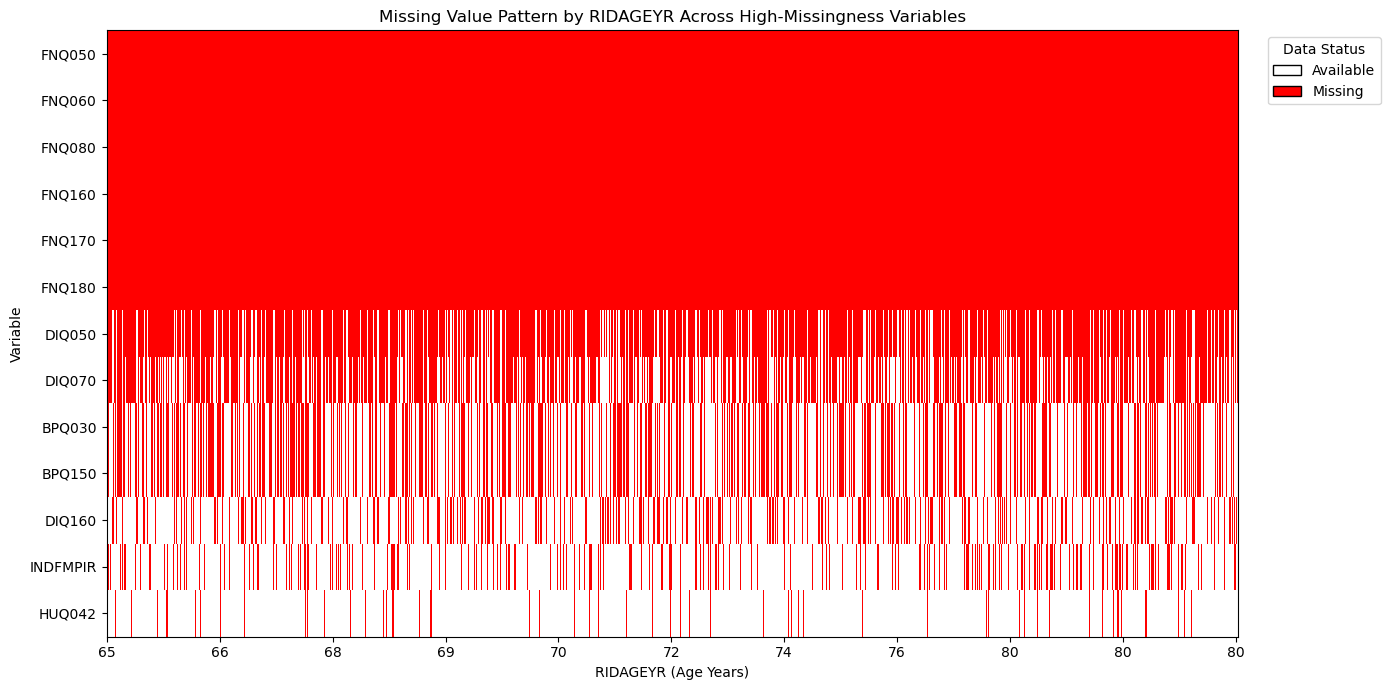

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Select variables to display in the missing value pattern plot
plot_vars = [
    'FNQ050', 'FNQ060', 'FNQ080', 'FNQ160', 'FNQ170', 'FNQ180',
    'DIQ050', 'DIQ070', 'BPQ030', 'BPQ150', 'DIQ160',
    'INDFMPIR', 'HUQ042'
]

# Create a new dataframe containing age and the selected variables
plot_df = selected[['RIDAGEYR'] + plot_vars].copy()

# Sort the data by age so that the x-axis follows increasing age order
plot_df = plot_df.sort_values(by='RIDAGEYR').reset_index(drop=True)

# Create a missing-value matrix:
# missing values = 1, available values = 0
missing_matrix = plot_df.drop(columns=['RIDAGEYR']).isnull().T.astype(int)

# Define the color map:
# white = available, red = missing
cmap = ListedColormap(['white', 'red'])

# Create the plot
plt.figure(figsize=(14, 7))
plt.imshow(missing_matrix, aspect='auto', interpolation='none', cmap=cmap)

# Set variable names on the y-axis
plt.yticks(range(len(missing_matrix.index)), missing_matrix.index)

# Create age labels on the x-axis at regular intervals
x_positions = range(0, len(plot_df), max(1, len(plot_df)//10))
x_labels = plot_df.loc[list(x_positions), 'RIDAGEYR'].astype(int).tolist()
plt.xticks(x_positions, x_labels)

# Add axis labels and title
plt.xlabel('RIDAGEYR (Age Years)')
plt.ylabel('Variable')
plt.title('Missing Value Pattern by RIDAGEYR Across High-Missingness Variables')

# Create a custom legend
legend_elements = [
    Patch(facecolor='white', edgecolor='black', label='Available'),
    Patch(facecolor='red', edgecolor='black', label='Missing')
]
plt.legend(handles=legend_elements, title='Data Status',
           bbox_to_anchor=(1.02, 1), loc='upper left')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

### Figure: Missing Value Pattern

Missing values were inspected for all selected variables after the initial variable screening step. The results showed that missingness was not evenly distributed across variables.

Several variables had extremely high levels of missing values, including `FNQ050`, `FNQ060`, `FNQ080`, `FNQ160`, `FNQ170`, and `FNQ180`, each with 2586 missing observations. These variables were considered unsuitable for the first-stage analysis because they contained little or no usable information in the elderly sample.

Some variables showed moderate to high missingness, such as `DIQ050`, `DIQ070`, `BPQ030`, `BPQ150`, `DIQ160`, `INDFMPIR`, and `HUQ042`. These variables may be condition-specific or only applicable to certain respondents. In contrast, many core demographic, chronic disease, health status, and healthcare access variables had very few or no missing values.

Overall, the missing value inspection provided a basis for removing variables with excessive missingness and retaining variables with better completeness for the next stage of preprocessing.

In [11]:
drop_cols = [
    'FNQ050', 'FNQ060', 'FNQ080', 'FNQ160', 'FNQ170', 'FNQ180',
    'DIQ050', 'DIQ070', 'BPQ030', 'BPQ150', 'DIQ160'
]

selected = selected.drop(columns=drop_cols)
print(selected.shape)

(2586, 36)


In [12]:
keep_core = [
    'SEQN',
    'RIAGENDR',
    'RIDAGEYR',
    'RIDRETH1',
    'INDFMPIR',

    'DIQ010',
    'BPQ020',
    'BPQ080',
    'BPQ101D',

    'MCQ160A',
    'MCQ160B',
    'MCQ160C',
    'MCQ160D',
    'MCQ160E',
    'MCQ160F',
    'MCQ160L',
    'MCQ160P',
    'MCQ220',
    'MCQ550',
    'MCQ560',

    'HUQ010',
    'HUQ030',
    'HUQ042',
    'HUQ090',

    'FNQ410',
    'FNQ430',
    'FNQ440',
    'FNQ450',
    'FNQ460',
    'FNQ470',
    'FNQ480',
    'FNQ490',
    'FNQ510',
    'FNQ530',
    'FNDADI',
    'FNDAEDI'
]

selected2 = merged[keep_core].copy()
print(selected2.shape)


(2586, 36)


In [13]:
for col in selected2.columns:
    print("\n", col)
    print(selected2[col].value_counts(dropna=False).head(10))


 SEQN
SEQN
130379.0    1
138244.0    1
138368.0    1
138369.0    1
138384.0    1
138391.0    1
138392.0    1
138399.0    1
138405.0    1
138406.0    1
Name: count, dtype: int64

 RIAGENDR
RIAGENDR
2.0    1421
1.0    1165
Name: count, dtype: int64

 RIDAGEYR
RIDAGEYR
80.0    525
68.0    193
70.0    187
67.0    181
65.0    179
71.0    159
73.0    154
69.0    149
66.0    145
72.0    145
Name: count, dtype: int64

 RIDRETH1
RIDRETH1
3.0    1780
5.0     271
4.0     257
2.0     187
1.0      91
Name: count, dtype: int64

 INDFMPIR
INDFMPIR
5.00    478
NaN     470
3.28     27
2.18     21
4.37     20
2.58     20
2.73     18
3.55     17
0.88     17
3.04     16
Name: count, dtype: int64

 DIQ010
DIQ010
2.0    1900
1.0     557
3.0     127
NaN       1
9.0       1
Name: count, dtype: int64

 BPQ020
BPQ020
1.0    1522
2.0    1057
9.0       5
NaN       1
7.0       1
Name: count, dtype: int64

 BPQ080
BPQ080
1.0    1492
2.0    1060
9.0      33
NaN       1
Name: count, dtype: int64

 BPQ101D
BPQ101D
1.

The selected variables were further examined by checking their value distributions. This step helped identify the coding structure of each variable, including binary response variables, ordinal health-status variables, and functioning variables with multiple response levels.

The inspection showed that many chronic condition variables used a Yes/No format, where `1` generally represented “Yes” and `2` represented “No”. Some variables also contained special response codes such as `7`, `9`, or `99`, which indicated refused, unknown, or inapplicable responses. In addition, several health and functioning variables used ordered categories rather than simple binary values.

At this stage, the purpose of the inspection was to understand the variable structure before recoding and cleaning. The findings from this step will guide the next phase of preprocessing, including handling special response codes, simplifying categorical responses, and preparing variables for target construction and machine learning analysis.